In [29]:
import pickle
import os
import sys
import torch
import numpy as np
import csv
import matplotlib.pyplot as plt
import pandas as pd
import tifffile

In [2]:
sys.path.append('/home/omer/git/AutoDS3D')

In [3]:
from DS3Dplus.ds3d_utils import ImModel, Sampling, Volume2XYZ

In [4]:
param_dict_path = '/home/omer/data/mse3/train_data/param.pickle'

In [5]:
with open(param_dict_path, 'rb') as handle:
    param_dict = pickle.load(handle)

In [6]:
param_dict['threshold'] = 40

In [7]:
device = 'cuda:1'
param_dict['device'] = device

In [8]:
model = ImModel(param_dict)
volume2xyz = Volume2XYZ(param_dict)

In [9]:
# original data
frame_loc_csv_path = '/home/omer/git/AutoDS3D/experiments/mse3/beads/frame_0025.csv'
image_path = "/home/omer/experiments/mse3/BehindObj_001_range10_decomposedframes/frame_0025.tif"

In [20]:
# corrected data
corrected_frame_loc_csv_path = '/home/omer/git/AutoDS3D/experiments/mse3/beads_doda/frame_0025.csv'
corrected_image_path = '/home/omer/data/mse3/aberrated_data/train_data/outputs/MSE3 train fixed aberration n=3 no rotation with mse loss component/2026-03-02_18-26-15/outputs/experiments/BehindObj_001_range10_frames/frame_0025.tif'

In [21]:
df = pd.read_csv(corrected_frame_loc_csv_path)

In [22]:
df.head()

,x [nm],y [nm],z [nm],intensity [au]
0,89135.117188,6960.682129,20.532572,86.479607
1,45482.722656,7569.072754,20.628630,44.273232
2,88520.921875,8110.519531,28.497925,83.792664
3,87722.460938,8206.012695,26.572289,194.798019
4,88285.281250,8748.435547,28.662327,165.928146


In [23]:
df_filtered = df[(df['z [nm]']>=1475)&(df['z [nm]']<=1525)]

In [24]:
df_filtered.count()

x [nm]            170
y [nm]            170
z [nm]            170
intensity [au]    170
dtype: int64

In [25]:
xyzps = df_filtered.to_numpy()[:, :4]

In [26]:
xyzps

array([[7.11971094e+04, 6.17085938e+04, 1.48605273e+03, 1.00000000e+03],
       [7.12002031e+04, 6.17093008e+04, 1.48646057e+03, 1.00000000e+03],
       [7.11971094e+04, 6.17085938e+04, 1.48605273e+03, 1.00000000e+03],
       [7.12004922e+04, 6.17096250e+04, 1.48632056e+03, 1.00000000e+03],
       [7.12216094e+04, 6.17124883e+04, 1.48382654e+03, 1.00000000e+03],
       [6.77058906e+04, 6.96839766e+04, 1.48153125e+03, 1.00000000e+03],
       [6.77218516e+04, 6.96884609e+04, 1.48331592e+03, 1.00000000e+03],
       [6.77218516e+04, 6.96884609e+04, 1.48331592e+03, 1.00000000e+03],
       [6.77058906e+04, 6.96839766e+04, 1.48153125e+03, 1.00000000e+03],
       [6.77218516e+04, 6.96884609e+04, 1.48331592e+03, 1.00000000e+03],
       [6.77221094e+04, 6.96886406e+04, 1.48322412e+03, 1.00000000e+03],
       [6.77218594e+04, 6.96885938e+04, 1.48333875e+03, 1.00000000e+03],
       [6.77221250e+04, 6.96887656e+04, 1.48324683e+03, 1.00000000e+03],
       [6.55683672e+04, 7.26774297e+04, 1.48095654e

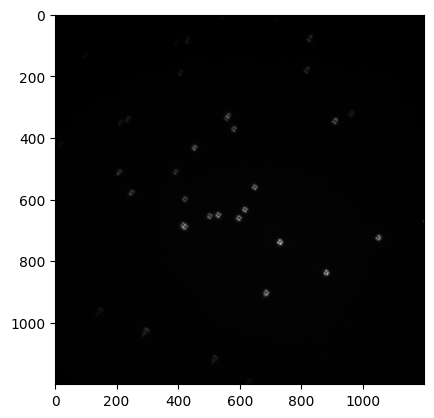

In [ ]:
import tifffile
im = tifffile.imread(corrected_image_path)
plt.imshow(im, cmap='gray')

In [31]:
model.Xgrid.shape, model.W

(torch.Size([609, 609]), 120)

In [32]:
from torch.nn.functional import interpolate

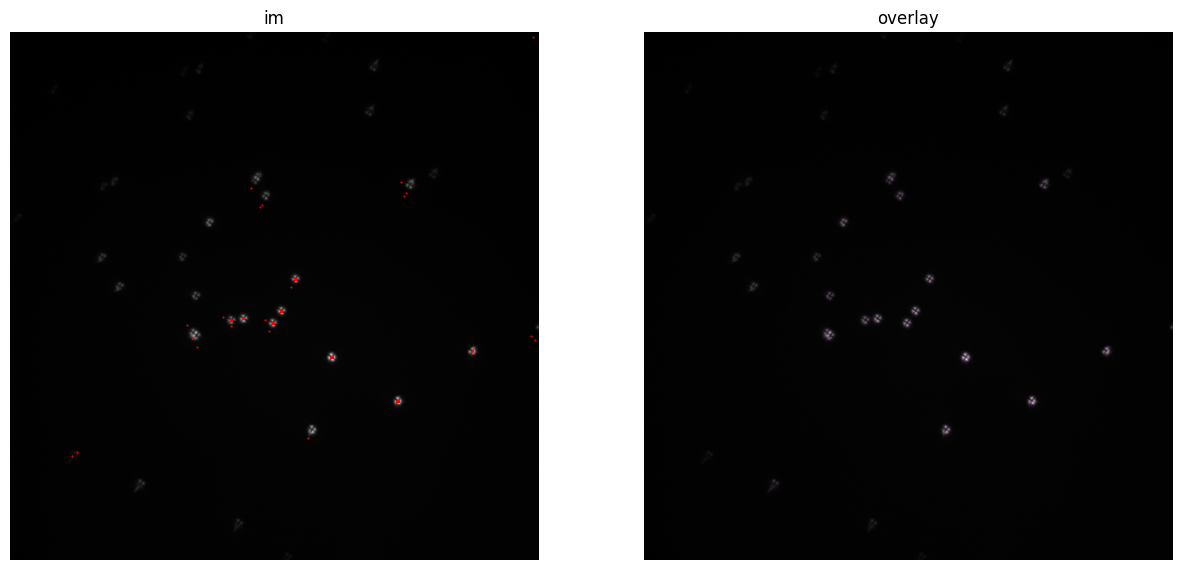

In [ ]:
if xyzps is not None:
    xyz_rec = xyzps[:, :3]
    im = tifffile.imread(image_path)
    H, W = im.shape
    param_dict['H'], param_dict['W'] = H, W

    if H > param_dict['phase_mask'].shape[0] or W > param_dict['phase_mask'].shape[1]:
        sf = max(H // param_dict['phase_mask'].shape[0] + 1, W // param_dict['phase_mask'].shape[1] + 1)
        param_dict['ps_BFP'] /= sf
        phase_mask = param_dict['phase_mask']
        HW = np.floor(param_dict['f_4f'] * param_dict['lamda'] / (
                param_dict['ps_camera'] * param_dict['ps_BFP']))  # simulation size
        HW = int(HW + 1 - (HW % 2))  # make it odd

        phase_mask = interpolate(torch.tensor(phase_mask).unsqueeze(0).unsqueeze(1), size=(HW, HW))
        param_dict['phase_mask'] = phase_mask[0, 0].numpy()
        model = ImModel(param_dict)
    nphotons_rec = (param_dict['Nsig_range'][0]+param_dict['Nsig_range'][1])/2 * np.ones(xyz_rec.shape[0])
    psfs_rec = model.get_psfs(torch.from_numpy(np.c_[xyz_rec, nphotons_rec]).to(device)).cpu().numpy()
    im = (im-im.min())/(im.max()-im.min())
    
    ps_xy = param_dict['vs_xy']*param_dict['us_factor']
    h, w = im.shape
    ch, cw = (h-1)/2, (w-1)/2
    
    fig = plt.figure(figsize=(15, 8))
    plt.subplot(1, 2, 1)
    plt.imshow(im, cmap='gray')
    plt.plot(xyz_rec[:, 0] / (ps_xy*1000), xyz_rec[:, 1] / (ps_xy*1000), 'r.', markersize=1)
    plt.title('im')
    plt.axis('off')

    mask = np.max(psfs_rec, axis=0)
    mask = (mask-mask.min())/(mask.max()-mask.min())
    mask = 1-mask
    # transparency = 0.2+mask*0.8
    # im_overlay = np.stack((im, im, im, transparency), axis=-1)
    im_overlay = np.stack((im, im, im), axis=-1)
    im_overlay[:, :, 1] = im_overlay[:, :, 1] * mask
    plt.subplot(1, 2, 2)
    plt.imshow(im_overlay)
    plt.title('overlay')
    plt.axis('off')
    plt.show()
    
else:
    print('xyzps is empty.')